# Multi-Task Learning

- Shared backbone: ResNet-18 (pretrained on ImageNet)
- Task-specific heads:
  - Myopic maculopathy grade classification (CrossEntropy)
  - Age regression (MSE loss)
  - Sex classification (Binary CrossEntropy)

## Loss Balancing
GradNorm:

$$\mathcal{L}_{total} = w_1 \mathcal{L}_{grade} + w_2 \mathcal{L}_{age} + w_3 \mathcal{L}_{sex}$$

In [2]:
import os
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
DATA_ROOT = os.path.join("..", "Data")
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "Training", "Training_Images")
TRAIN_CSV = os.path.join(DATA_ROOT, "Training", "Training_LabelsDemographic.csv")
TEST_IMG_DIR = os.path.join(DATA_ROOT, "Testing", "Testing_Images")
TEST_CSV = os.path.join(DATA_ROOT, "Testing", "Testing_LabelDemographic.csv")

# CSVs
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")
print(f"\nGrade distribution (train):")
print(train_df["myopic_maculopathy_grade"].value_counts().sort_index())
print(f"\nMissing sex (train): {train_df['sex'].isnull().sum()}/{len(train_df)}")
print(f"Missing sex (test): {test_df['sex'].isnull().sum()}/{len(test_df)}")

Training samples: 1143
Testing samples: 248

Grade distribution (train):
myopic_maculopathy_grade
0    404
1    412
2    224
3     60
4     43
Name: count, dtype: int64

Missing sex (train): 153/1143
Missing sex (test): 33/248


In [4]:
class MyopicMaculopathyDataset(Dataset):
    """Dataset for multi-task learning."""

    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        # Precompute normalised age (z-score)
        self.age_mean = self.df["age"].mean()
        self.age_std = self.df["age"].std()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row["image"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Primary task: maculopathy grade (0-4)
        grade = torch.tensor(row["myopic_maculopathy_grade"], dtype=torch.long)

        # task 2: age (normalised)
        age_norm = (row["age"] - self.age_mean) / self.age_std
        age = torch.tensor(age_norm, dtype=torch.float32)

        # task 3: sex (binary, with validity mask)
        if pd.isna(row["sex"]):
            sex = torch.tensor(0.0, dtype=torch.float32)
            sex_valid = torch.tensor(0.0, dtype=torch.float32)
        else:
            sex = torch.tensor(1.0 if row["sex"] == "female" else 0.0, dtype=torch.float32)
            sex_valid = torch.tensor(1.0, dtype=torch.float32)

        return image, grade, age, sex, sex_valid

In [5]:
# image transforms
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# datasets
train_dataset = MyopicMaculopathyDataset(train_df, TRAIN_IMG_DIR, transform=train_transform)
test_dataset = MyopicMaculopathyDataset(test_df, TEST_IMG_DIR, transform=test_transform)

# training set age stats
test_dataset.age_mean = train_dataset.age_mean
test_dataset.age_std = train_dataset.age_std

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 36, Test batches: 8


### Visualisation of the sample images with their labels

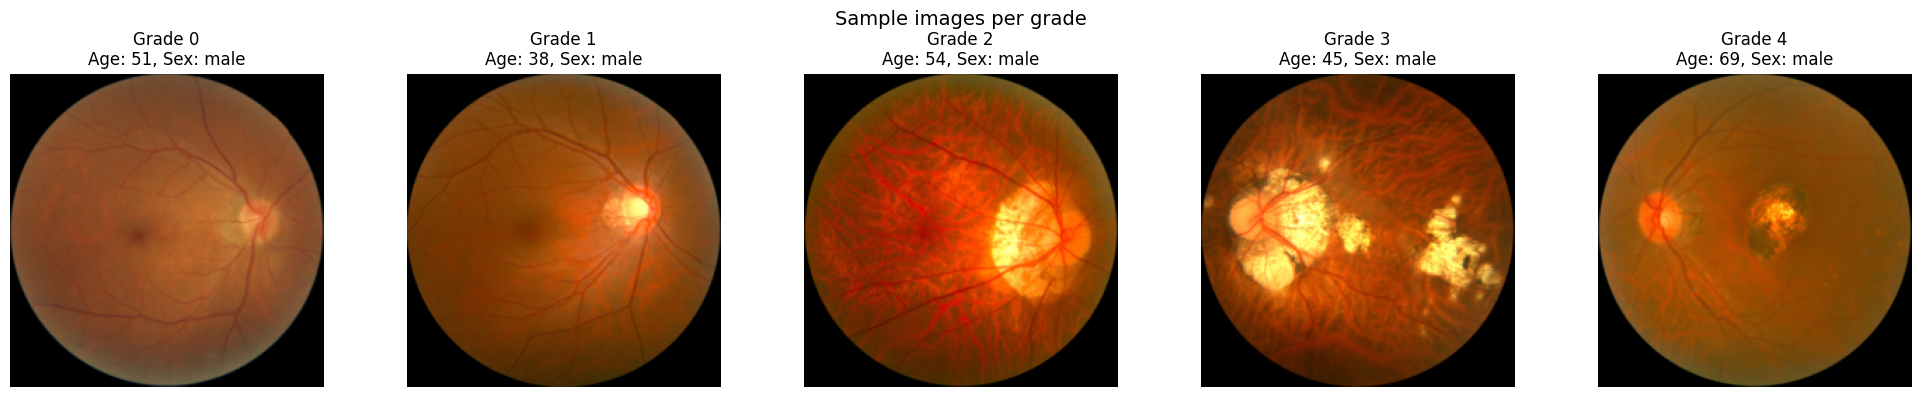

In [6]:
# one sample per grade (unnormalised)
vis_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    idx = train_df[train_df["myopic_maculopathy_grade"] == grade].index[0]
    img_path = os.path.join(TRAIN_IMG_DIR, train_df.iloc[idx]["image"])
    img = vis_transform(Image.open(img_path).convert("RGB"))
    axes[grade].imshow(img.permute(1, 2, 0))
    axes[grade].set_title(f"Grade {grade}\nAge: {train_df.iloc[idx]['age']}, Sex: {train_df.iloc[idx]['sex']}")
    axes[grade].axis("off")
plt.suptitle("Sample images per grade", fontsize=14)
plt.tight_layout()
plt.show()

## Multi-Task Learning Model

In [7]:
class MultiTaskResNet(nn.Module):
    """Multi-task ResNet-18 with shared backbone and 3 task-specific heads."""

    def __init__(self, num_grades=5, pretrained=True):
        super(MultiTaskResNet, self).__init__()

        # shared backbone: ResNet-18 without the final FC layer
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        self.shared_encoder = nn.Sequential(*list(backbone.children())[:-1]) # output: (B, 512, 1, 1)

        # grade classification head
        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades),
        )

        # age regression head
        self.age_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

        # sex classification head
        self.sex_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # Shared feature extraction
        features = self.shared_encoder(x) # (B, 512, 1, 1)
        features = features.view(features.size(0), -1) # (B, 512)

        # Task-specific predictions
        grade_logits = self.grade_head(features) # (B, 5)
        age_pred = self.age_head(features).squeeze(1) # (B,)
        sex_logits = self.sex_head(features).squeeze(1) # (B,)

        return grade_logits, age_pred, sex_logits

    def get_shared_params(self):
        return list(self.shared_encoder.parameters())

model = MultiTaskResNet(num_grades=5, pretrained=True).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Shared encoder params: {sum(p.numel() for p in model.shared_encoder.parameters()):,}")

Total parameters: 11,440,711
Shared encoder params: 11,176,512


### Loss Functions
- Grade: CrossEntropy loss (multi-class classification)
- Age: MSE loss (regression on z-score normalised age)
- Sex: Binary CrossEntropy with logits

In [8]:
# Loss functions for each task
criterion_grade = nn.CrossEntropyLoss()
criterion_age = nn.MSELoss()
criterion_sex = nn.BCEWithLogitsLoss(reduction="none") # per-sample for masking


def compute_masked_sex_loss(sex_logits, sex_targets, sex_valid):
    """Compute sex loss only for samples with valid sex labels."""
    per_sample_loss = criterion_sex(sex_logits, sex_targets)
    masked_loss = per_sample_loss * sex_valid
    n_valid = sex_valid.sum()
    if n_valid > 0:
        return masked_loss.sum() / n_valid
    else:
        return torch.tensor(0.0, device=sex_logits.device, requires_grad=True)

## Evaluation

In [9]:
def evaluate_model(model, dataloader):
    """Evaluate the model on grade classification."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            grade_logits, _, _ = model(images)
            preds = grade_logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(grades.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return acc, f1, kappa


def full_evaluation(model, dataloader, dataset_name="Test"):
    """classification report and confusion matrix."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            grade_logits, _, _ = model(images)
            all_preds.extend(grade_logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(grades.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(f" {dataset_name} Evaluation: ")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
    print(f"Quadratic Kappa: {cohen_kappa_score(all_labels, all_preds, weights='quadratic'):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds,
          target_names=[f"Grade {i}" for i in range(5)], zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
    ax.set_xlabel("Predicted Grade")
    ax.set_ylabel("True Grade")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_title(f"Confusion Matrix ({dataset_name} Set)")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

## Training with GradNorm

In [10]:
def train_mtl_gradnorm(model, train_loader, test_loader, num_epochs=30, lr=1e-4, alpha=0.5):
    """Multi-task model training using GradNorm."""
    num_tasks = 3

    # learnable GradNorm task weights
    task_weights = torch.ones(num_tasks, device=device, requires_grad=True)

    # separate optimisers for model parameters and task weights
    optimizer_model = optim.Adam(model.parameters(), lr=lr)
    optimizer_weights = optim.Adam([task_weights], lr=5e-4)

    # cosine annealing schedule
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_model, T_max=num_epochs)

    # L1 loss
    grad_norm_loss_fn = nn.L1Loss()

    # reference to last shared layer
    shared_layer = list(model.shared_encoder.parameters())[-2] # for gradient computation

    history = {
        "train_loss": [], "grade_loss": [], "age_loss": [], "sex_loss": [],
        "w_grade": [], "w_age": [], "w_sex": [],
        "test_acc": [], "test_f1": [], "test_kappa": [],
    }

    # initial loss values
    L0 = [None, None, None]

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = {"total": 0, "grade": 0, "age": 0, "sex": 0}
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", file=sys.stdout)
        for images, grades, ages, sexes, sex_valid in pbar:
            images = images.to(device)
            grades = grades.to(device)
            ages = ages.to(device)
            sexes = sexes.to(device)
            sex_valid = sex_valid.to(device)

            # pass through all three heads
            grade_logits, age_pred, sex_logits = model(images)

            # Per-task losses
            loss_grade = criterion_grade(grade_logits, grades)
            loss_age = criterion_age(age_pred, ages)
            loss_sex = compute_masked_sex_loss(sex_logits, sexes, sex_valid)
            losses = [loss_grade, loss_age, loss_sex]

            # initial losses on first batch
            if L0[0] is None:
                L0 = [l.detach().clone() for l in losses]

            # weighted total loss: L = sum(w_i * L_i)
            total_loss = sum(task_weights[i] * losses[i] for i in range(num_tasks))

            # backward pass
            optimizer_model.zero_grad()
            total_loss.backward(retain_graph=True)

            # per-task gradient norms on the last shared layer
            G_norms = []
            for i in range(num_tasks):
                g = torch.autograd.grad(
                    task_weights[i] * losses[i], shared_layer,
                    retain_graph=True, create_graph=True
                )[0]
                G_norms.append(torch.norm(g, 2))

            G_avg = sum(G_norms) / num_tasks

            # how fast each task is learning
            r = [losses[i].detach() / (L0[i] + 1e-8) for i in range(num_tasks)]
            r_avg = sum(r) / num_tasks
            r_rel = [r[i] / (r_avg + 1e-8) for i in range(num_tasks)]

            # gradient magnitudes
            G_targets = [G_avg.detach() * (r_rel[i] ** alpha) for i in range(num_tasks)]

            # GradNorm loss: push each G_i towards its target
            gradnorm_loss = sum(
                grad_norm_loss_fn(G_norms[i], G_targets[i]) for i in range(num_tasks)
            )

            # update task weights
            optimizer_weights.zero_grad()
            gradnorm_loss.backward()
            optimizer_weights.step()

            # update model parameters
            optimizer_model.step()

            # renormalise weights: sum(w_i) = num_tasks
            with torch.no_grad():
                task_weights.data = task_weights.data / task_weights.data.sum() * num_tasks
                task_weights.data = task_weights.data.clamp(min=0.1)

            # accumulate epoch losses
            epoch_losses["total"] += total_loss.item()
            epoch_losses["grade"] += loss_grade.item()
            epoch_losses["age"] += loss_age.item()
            epoch_losses["sex"] += loss_sex.item()
            n_batches += 1

            pbar.set_postfix({
                "loss": f"{total_loss.item():.3f}",
                "w": f"[{task_weights[0].item():.2f}, {task_weights[1].item():.2f}, {task_weights[2].item():.2f}]"
            })

        scheduler.step()

        # epoch averages
        for k in epoch_losses:
            epoch_losses[k] /= n_batches
        history["train_loss"].append(epoch_losses["total"])
        history["grade_loss"].append(epoch_losses["grade"])
        history["age_loss"].append(epoch_losses["age"])
        history["sex_loss"].append(epoch_losses["sex"])
        history["w_grade"].append(task_weights[0].item())
        history["w_age"].append(task_weights[1].item())
        history["w_sex"].append(task_weights[2].item())

        # Evaluation on test set
        acc, f1, kappa = evaluate_model(model, test_loader)
        history["test_acc"].append(acc)
        history["test_f1"].append(f1)
        history["test_kappa"].append(kappa)

        print(f" Losses - Total: {epoch_losses['total']:.4f}, "
              f"Grade: {epoch_losses['grade']:.4f}, Age: {epoch_losses['age']:.4f}, "
              f"Sex: {epoch_losses['sex']:.4f}")
        print(f" Weights - Grade: {task_weights[0].item():.3f}, "
              f"Age: {task_weights[1].item():.3f}, Sex: {task_weights[2].item():.3f}")
        print(f" Test Acc: {acc:.4f}, F1 (macro): {f1:.4f}, Kappa: {kappa:.4f}")

    return history

## Training the Multi-Task Model

In [11]:
NUM_EPOCHS = 30

model = MultiTaskResNet(num_grades=5, pretrained=True).to(device)
history = train_mtl_gradnorm(
    model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, lr=1e-4, alpha=0.5
)

Epoch 1/30: 100%|██████████| 36/36 [01:48<00:00,  3.02s/it, loss=1.724, w=[1.01, 0.98, 1.01]]
 Losses - Total: 2.3779, Grade: 1.0164, Age: 0.7467, Sex: 0.6142
 Weights - Grade: 1.009, Age: 0.979, Sex: 1.012
 Test Acc: 0.6411, F1 (macro): 0.3987, Kappa: 0.6447
Epoch 2/30: 100%|██████████| 36/36 [01:46<00:00,  2.95s/it, loss=1.614, w=[1.01, 0.96, 1.03]]
 Losses - Total: 1.7110, Grade: 0.6334, Age: 0.4864, Sex: 0.5875
 Weights - Grade: 1.009, Age: 0.963, Sex: 1.028
 Test Acc: 0.6694, F1 (macro): 0.4237, Kappa: 0.6808
Epoch 3/30: 100%|██████████| 36/36 [01:44<00:00,  2.89s/it, loss=1.917, w=[1.01, 0.95, 1.05]]
 Losses - Total: 1.4934, Grade: 0.5265, Age: 0.3992, Sex: 0.5611
 Weights - Grade: 1.006, Age: 0.949, Sex: 1.045
 Test Acc: 0.7137, F1 (macro): 0.5287, Kappa: 0.7623
Epoch 4/30: 100%|██████████| 36/36 [01:51<00:00,  3.10s/it, loss=1.354, w=[1.00, 0.94, 1.06]]
 Losses - Total: 1.3570, Grade: 0.4715, Age: 0.3440, Sex: 0.5308
 Weights - Grade: 1.001, Age: 0.935, Sex: 1.064
 Test Acc: 0.

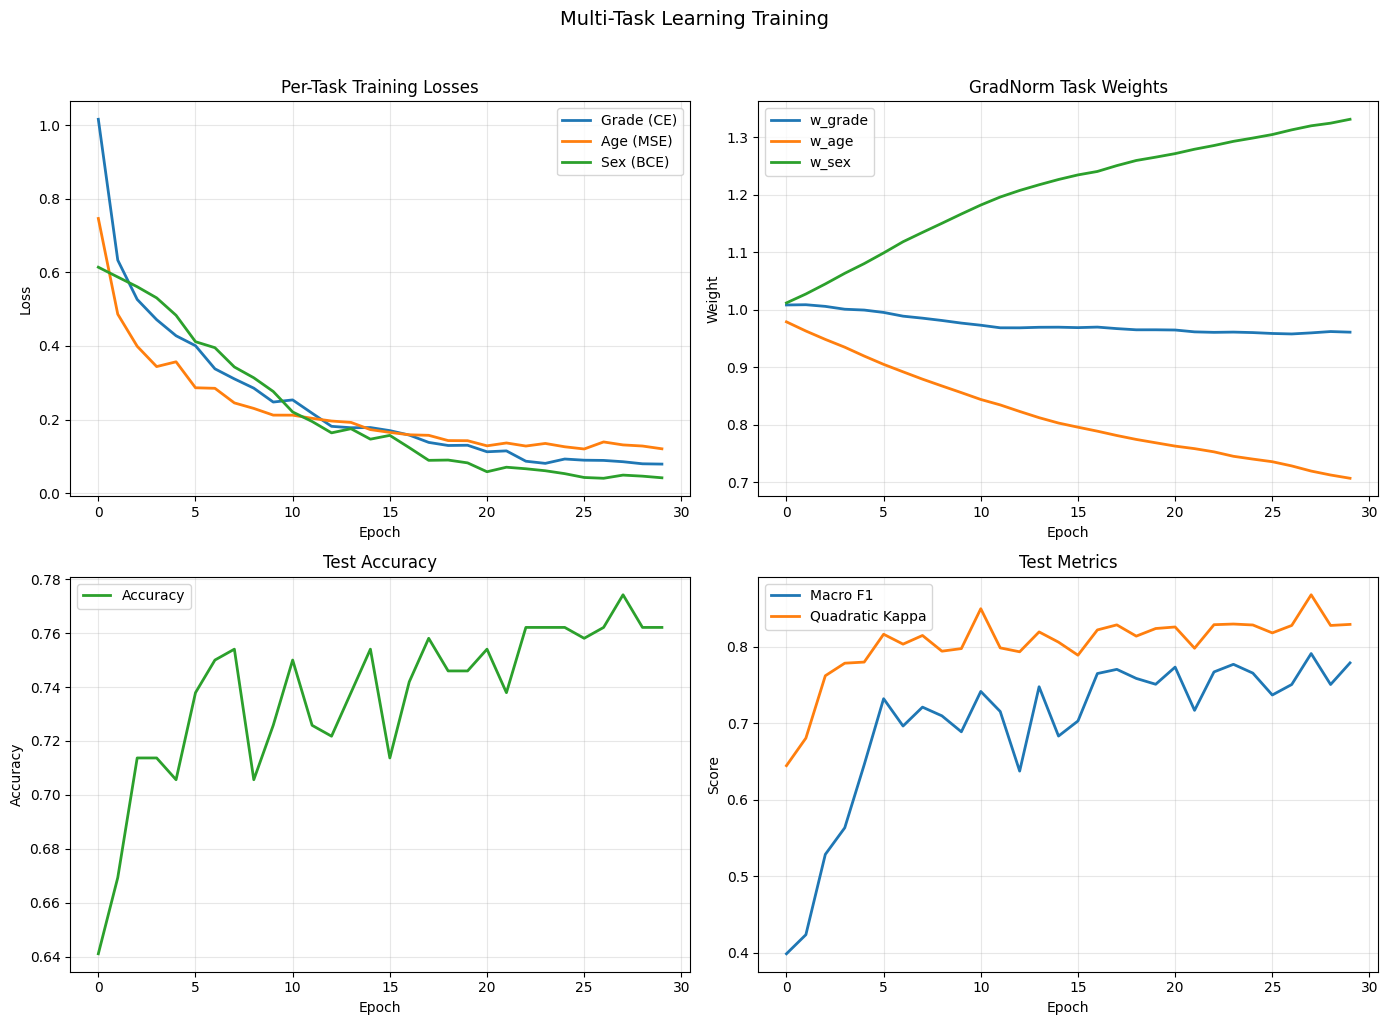

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-task training losses
axes[0, 0].plot(history["grade_loss"], label="Grade (CE)", linewidth=2)
axes[0, 0].plot(history["age_loss"], label="Age (MSE)", linewidth=2)
axes[0, 0].plot(history["sex_loss"], label="Sex (BCE)", linewidth=2)
axes[0, 0].set_title("Per-Task Training Losses")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# GradNorm learned task weights
axes[0, 1].plot(history["w_grade"], label="w_grade", linewidth=2)
axes[0, 1].plot(history["w_age"], label="w_age", linewidth=2)
axes[0, 1].plot(history["w_sex"], label="w_sex", linewidth=2)
axes[0, 1].set_title("GradNorm Task Weights")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Weight")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test accuracy
axes[1, 0].plot(history["test_acc"], label="Accuracy", linewidth=2, color="tab:green")
axes[1, 0].set_title("Test Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test F1 and Kappa
axes[1, 1].plot(history["test_f1"], label="Macro F1", linewidth=2)
axes[1, 1].plot(history["test_kappa"], label="Quadratic Kappa", linewidth=2)
axes[1, 1].set_title("Test Metrics")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Multi-Task Learning Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set

 Test Evaluation: 
Accuracy: 0.7621
Macro F1: 0.7791
Quadratic Kappa: 0.8295

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.81      0.86      0.84        80
     Grade 1       0.61      0.79      0.69        78
     Grade 2       0.93      0.63      0.75        65
     Grade 3       1.00      0.67      0.80        12
     Grade 4       1.00      0.69      0.82        13

    accuracy                           0.76       248
   macro avg       0.87      0.73      0.78       248
weighted avg       0.80      0.76      0.77       248



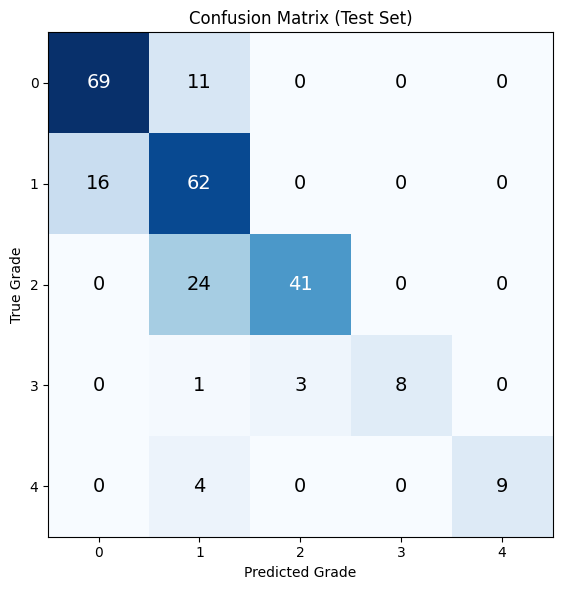

In [13]:
preds, labels = full_evaluation(model, test_loader, dataset_name="Test")

## Task Evaluation

Evaluate age regression (MAE) and sex classification (accuracy) on the test set.

Task Evaluation (Test Set)
Age regression MAE: 5.42 years
Sex classification accuracy: 0.6884 (215 valid samples)


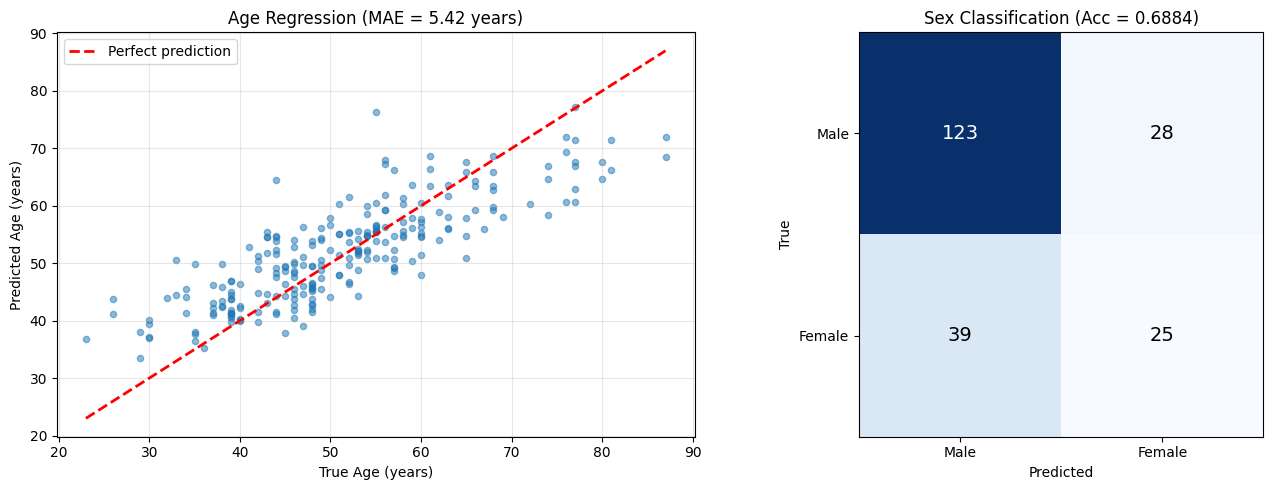

In [15]:
def evaluate_tasks(model, dataloader, age_mean, age_std):
    """Evaluate task performance (age MAE, sex accuracy)."""
    model.eval()
    age_preds, age_labels = [], []
    sex_preds, sex_labels = [], []

    with torch.no_grad():
        for images, grades, ages, sexes, sex_valid in dataloader:
            images = images.to(device)
            _, age_pred, sex_logits = model(images)

            # de-normalise age predictions
            age_pred_years = age_pred.cpu().numpy() * age_std + age_mean
            age_true_years = ages.numpy() * age_std + age_mean
            age_preds.extend(age_pred_years)
            age_labels.extend(age_true_years)

            # sex (only valid samples)
            valid_mask = sex_valid.bool()
            if valid_mask.any():
                sex_pred = (sex_logits.cpu() > 0).float()
                sex_preds.extend(sex_pred[valid_mask].numpy())
                sex_labels.extend(sexes[valid_mask].numpy())

    age_preds = np.array(age_preds)
    age_labels = np.array(age_labels)
    sex_preds = np.array(sex_preds)
    sex_labels = np.array(sex_labels)

    age_mae = np.mean(np.abs(age_preds - age_labels))
    sex_acc = accuracy_score(sex_labels, sex_preds) if len(sex_labels) > 0 else float('nan')

    print(f"Task Evaluation (Test Set)")
    print(f"Age regression MAE: {age_mae:.2f} years")
    print(f"Sex classification accuracy: {sex_acc:.4f} ({len(sex_labels)} valid samples)")

    # age prediction scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(age_labels, age_preds, alpha=0.5, s=20)
    min_age, max_age = min(age_labels.min(), age_preds.min()), max(age_labels.max(), age_preds.max())
    axes[0].plot([min_age, max_age], [min_age, max_age], 'r--', linewidth=2, label='Perfect prediction')
    axes[0].set_xlabel('True Age (years)')
    axes[0].set_ylabel('Predicted Age (years)')
    axes[0].set_title(f'Age Regression (MAE = {age_mae:.2f} years)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # sex confusion matrix
    if len(sex_labels) > 0:
        cm_sex = confusion_matrix(sex_labels, sex_preds)
        im = axes[1].imshow(cm_sex, cmap='Blues')
        for i in range(cm_sex.shape[0]):
            for j in range(cm_sex.shape[1]):
                color = 'white' if cm_sex[i, j] > cm_sex.max() / 2 else 'black'
                axes[1].text(j, i, str(cm_sex[i, j]), ha='center', va='center', color=color, fontsize=14)
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_xticks([0, 1])
        axes[1].set_yticks([0, 1])
        axes[1].set_xticklabels(['Male', 'Female'])
        axes[1].set_yticklabels(['Male', 'Female'])
        axes[1].set_title(f'Sex Classification (Acc = {sex_acc:.4f})')

    plt.tight_layout()
    plt.show()

    return age_mae, sex_acc


age_mae, sex_acc = evaluate_tasks(
    model, test_loader,
    age_mean=train_dataset.age_mean,
    age_std=train_dataset.age_std
)

## Comparison: Single-Task vs Multi-Task

In [16]:
class SingleTaskResNet(nn.Module):
    """Single-task ResNet-18 baseline (grade classification only)."""

    def __init__(self, num_grades=5, pretrained=True):
        super(SingleTaskResNet, self).__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        backbone.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)


def train_single_task(model_st, train_loader, test_loader, num_epochs=30, lr=1e-4):
    """Single-task baseline for comparison with MTL."""
    optimizer = optim.Adam(model_st.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    history_st = {"train_loss": [], "test_acc": [], "test_f1": [], "test_kappa": []}

    for epoch in range(num_epochs):
        model_st.train()
        running_loss = 0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"ST Epoch {epoch+1}/{num_epochs}", file=sys.stdout)
        for images, grades, _, _, _ in pbar:
            images, grades = images.to(device), grades.to(device)
            logits = model_st(images)
            loss = criterion(logits, grades)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.3f}"})

        scheduler.step()
        history_st["train_loss"].append(running_loss / n_batches)

        # Evaluation on test set
        model_st.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, grades, _, _, _ in test_loader:
                images = images.to(device)
                logits = model_st(images)
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(grades.numpy())

        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
        history_st["test_acc"].append(acc)
        history_st["test_f1"].append(f1)
        history_st["test_kappa"].append(kappa)

        print(f" Loss: {running_loss/n_batches:.4f}, Acc: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}")

    return history_st


# Train single-task baseline
model_st = SingleTaskResNet(num_grades=5, pretrained=True).to(device)
history_st = train_single_task(model_st, train_loader, test_loader, num_epochs=NUM_EPOCHS)

ST Epoch 1/30: 100%|██████████| 36/36 [01:11<00:00,  2.00s/it, loss=0.385]
 Loss: 0.8294, Acc: 0.6452, F1: 0.3962, Kappa: 0.6769
ST Epoch 2/30: 100%|██████████| 36/36 [01:12<00:00,  2.00s/it, loss=0.521]
 Loss: 0.5455, Acc: 0.7621, F1: 0.6998, Kappa: 0.8174
ST Epoch 3/30: 100%|██████████| 36/36 [01:11<00:00,  1.99s/it, loss=0.449]
 Loss: 0.4682, Acc: 0.7298, F1: 0.6571, Kappa: 0.8021
ST Epoch 4/30: 100%|██████████| 36/36 [01:13<00:00,  2.03s/it, loss=0.325]
 Loss: 0.3931, Acc: 0.7984, F1: 0.7865, Kappa: 0.8929
ST Epoch 5/30: 100%|██████████| 36/36 [01:12<00:00,  2.02s/it, loss=0.413]
 Loss: 0.3119, Acc: 0.7339, F1: 0.6354, Kappa: 0.7980
ST Epoch 6/30: 100%|██████████| 36/36 [01:12<00:00,  2.03s/it, loss=0.364]
 Loss: 0.2962, Acc: 0.7177, F1: 0.5765, Kappa: 0.7785
ST Epoch 7/30: 100%|██████████| 36/36 [01:13<00:00,  2.03s/it, loss=0.421]
 Loss: 0.2837, Acc: 0.7339, F1: 0.6695, Kappa: 0.8550
ST Epoch 8/30: 100%|██████████| 36/36 [01:12<00:00,  2.03s/it, loss=0.244]
 Loss: 0.2756, Acc: 0.

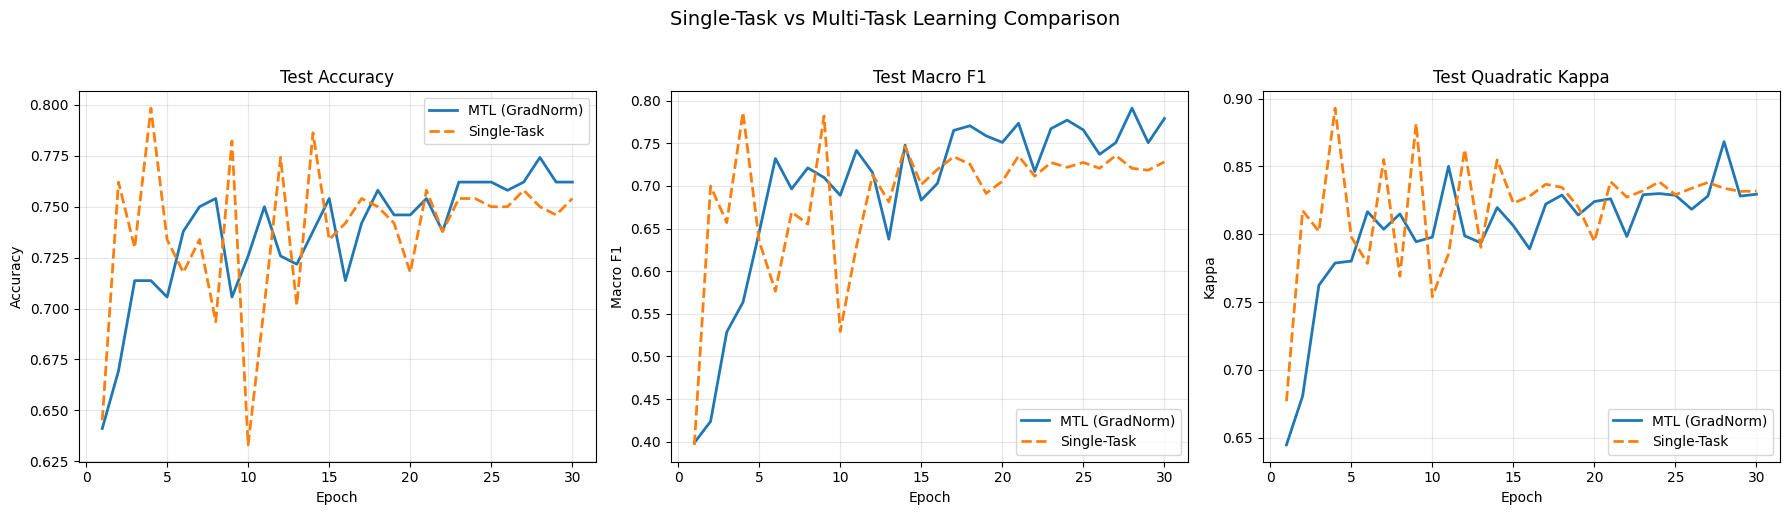

  Final Epoch Comparison
Metric                Single-Task          MTL
--------------------------------------------------
Accuracy                   0.7540       0.7621
Macro F1                   0.7283       0.7791
Quadratic Kappa            0.8318       0.8295


In [17]:
# comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["test_acc"], label="MTL (GradNorm)", linewidth=2)
axes[0].plot(epochs, history_st["test_acc"], label="Single-Task", linewidth=2, linestyle="--")
axes[0].set_title("Test Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["test_f1"], label="MTL (GradNorm)", linewidth=2)
axes[1].plot(epochs, history_st["test_f1"], label="Single-Task", linewidth=2, linestyle="--")
axes[1].set_title("Test Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["test_kappa"], label="MTL (GradNorm)", linewidth=2)
axes[2].plot(epochs, history_st["test_kappa"], label="Single-Task", linewidth=2, linestyle="--")
axes[2].set_title("Test Quadratic Kappa")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Kappa")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Single-Task vs Multi-Task Learning Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary
print(f"  Final Epoch Comparison")
print(f"{'Metric':<20} {'Single-Task':>12} {'MTL':>12}")
print(f"{'-'*50}")
print(f"{'Accuracy':<20} {history_st['test_acc'][-1]:>12.4f} {history['test_acc'][-1]:>12.4f}")
print(f"{'Macro F1':<20} {history_st['test_f1'][-1]:>12.4f} {history['test_f1'][-1]:>12.4f}")
print(f"{'Quadratic Kappa':<20} {history_st['test_kappa'][-1]:>12.4f} {history['test_kappa'][-1]:>12.4f}")

In [ ]:
save_path = os.path.join("..", "models")
os.makedirs(save_path, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_path, "mtl_resnet18_gradnorm.pt"))

import json
with open(os.path.join(save_path, "mtl_history.json"), "w") as f:
    json.dump(history, f)
with open(os.path.join(save_path, "st_history.json"), "w") as f:
    json.dump(history_st, f)